In [20]:
import yfinance as yf
import pandas as pd
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [4]:
import time

STOCKS = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS"]

def fetch_stock_data(symbol: str, period: str = "5y", interval: str = "1d") -> pd.DataFrame:
    try:
        print(f"📥 Fetching {symbol}...")
        df = yf.download(symbol, period=period, interval=interval, auto_adjust=True)

        if df.empty:
            print(f"⚠️ No data for {symbol}")
            return None

        # Fix MultiIndex columns (yfinance >= 0.2.x)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df.reset_index(inplace=True)

        # Rename Datetime to Date (for intraday intervals)
        if "Datetime" in df.columns:
            df.rename(columns={"Datetime": "Date"}, inplace=True)

        df["Symbol"] = symbol

        print(f"✅ {symbol} → {len(df)} rows fetched")
        return df

    except Exception as e:
        print(f"❌ Error fetching {symbol}: {e}")
        return None


def fetch_all_stocks() -> pd.DataFrame:
    all_data = []

    for stock in STOCKS:
        df = fetch_stock_data(stock)
        if df is not None:
            all_data.append(df)
        time.sleep(1)  # Avoid rate limiting

    if not all_data:
        print("❌ No data fetched")
        return None

    final_df = pd.concat(all_data, ignore_index=True)
    final_df.sort_values(by=["Symbol", "Date"], inplace=True)
    final_df.reset_index(drop=True, inplace=True)

    return final_df


def save_to_csv() -> None:
    df = fetch_all_stocks()

    if df is None:
        print("❌ Nothing to save")
        return

    # Drop duplicate rows if any
    df.drop_duplicates(subset=["Symbol", "Date"], inplace=True)

    df.to_csv("output.csv", index=False)
    print(f"\n✅ CSV saved successfully with {len(df)} total rows")
    print(df.groupby("Symbol").size().rename("rows"))  # Show row count per stock


save_to_csv()

📥 Fetching RELIANCE.NS...


[*********************100%***********************]  1 of 1 completed


✅ RELIANCE.NS → 1237 rows fetched
📥 Fetching TCS.NS...


[*********************100%***********************]  1 of 1 completed


✅ TCS.NS → 1237 rows fetched
📥 Fetching INFY.NS...


...

✅ INFY.NS → 1237 rows fetched
📥 Fetching HDFCBANK.NS...


[*********************100%***********************]  1 of 1 completed


✅ HDFCBANK.NS → 1237 rows fetched
📥 Fetching ICICIBANK.NS...


[*********************100%***********************]  1 of 1 completed


✅ ICICIBANK.NS → 1237 rows fetched

✅ CSV saved successfully with 6185 total rows
Symbol
HDFCBANK.NS     1237
ICICIBANK.NS    1237
INFY.NS         1237
RELIANCE.NS     1237
TCS.NS          1237
Name: rows, dtype: int64


In [5]:
# Style
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")

# Load
df = pd.read_csv("output.csv", parse_dates=["Date"])
df.sort_values(["Symbol", "Date"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(6185, 7)
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Symbol            object
dtype: object
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Symbol    0
dtype: int64


,Date,Close,High,Low,Open,Volume,Symbol
0,2021-04-26,665.296143,676.756944,664.325264,669.179539,30170952,HDFCBANK.NS
1,2021-04-27,681.350769,682.913632,665.296188,666.456455,20592906,HDFCBANK.NS
2,2021-04-28,699.394531,700.436401,677.704185,680.190522,24103940,HDFCBANK.NS
3,2021-04-29,697.358093,712.110366,691.911833,703.846224,24078552,HDFCBANK.NS
4,2021-04-30,668.848145,688.502040,666.574900,684.334444,35232902,HDFCBANK.NS


In [6]:
print("=" * 50)
print("Stocks in dataset:", df["Symbol"].unique())
print("Date range:", df["Date"].min(), "→", df["Date"].max())
print("Total rows:", len(df))
print("=" * 50)

df.groupby("Symbol")[["Close", "Volume"]].describe().round(2)

Stocks in dataset: ['HDFCBANK.NS' 'ICICIBANK.NS' 'INFY.NS' 'RELIANCE.NS' 'TCS.NS']
Date range: 2021-04-26 00:00:00 → 2026-04-24 00:00:00
Total rows: 6185


Close                                                       \
               count     mean     std      min      25%      50%      75%   
Symbol                                                                      
HDFCBANK.NS   1237.0   796.24   99.87   616.52   718.71   782.21   845.62   
ICICIBANK.NS  1237.0  1017.76  264.27   571.70   794.06   951.75  1260.87   
INFY.NS       1237.0  1478.33  180.07  1122.01  1349.93  1458.18  1580.14   
RELIANCE.NS   1237.0  1250.83  166.56   867.48  1128.28  1221.51  1407.18   
TCS.NS        1237.0  3256.41  405.39  2356.00  2971.19  3166.91  3460.31   

                       Volume                                             \
                  max   count         mean          std  min         25%   
Symbol                                                                     
HDFCBANK.NS   1012.90  1237.0  26250210.80  25090909.23  0.0  13150406.0   
ICICIBANK.NS  1477.20  1237.0  14035957.76   7639557.19  0.0   9222544.0   
INFY.NS       1942.22  1237.0   7123129.02   4464508.28  0.0   4596579.0   
RELIANCE.NS   1592.30  1237.0  13446237.75   7347531.99  0.0   8910166.0   
TCS.NS        4311.59  1237.0   2445121.47   1367518.18  0.0   1618931.0   

                                                   
                     50%         75%          max  
Symbol                                             
HDFCBANK.NS   20498102.0  32722086.0  445342100.0  
ICICIBANK.NS  12267898.0  16661023.0   96124084.0  
INFY.NS        6119965.0   8169075.0   53171705.0  
RELIANCE.NS   11785109.0  16027522.0   91461975.0  
TCS.NS         2070859.0   2888572.0   13509164.0

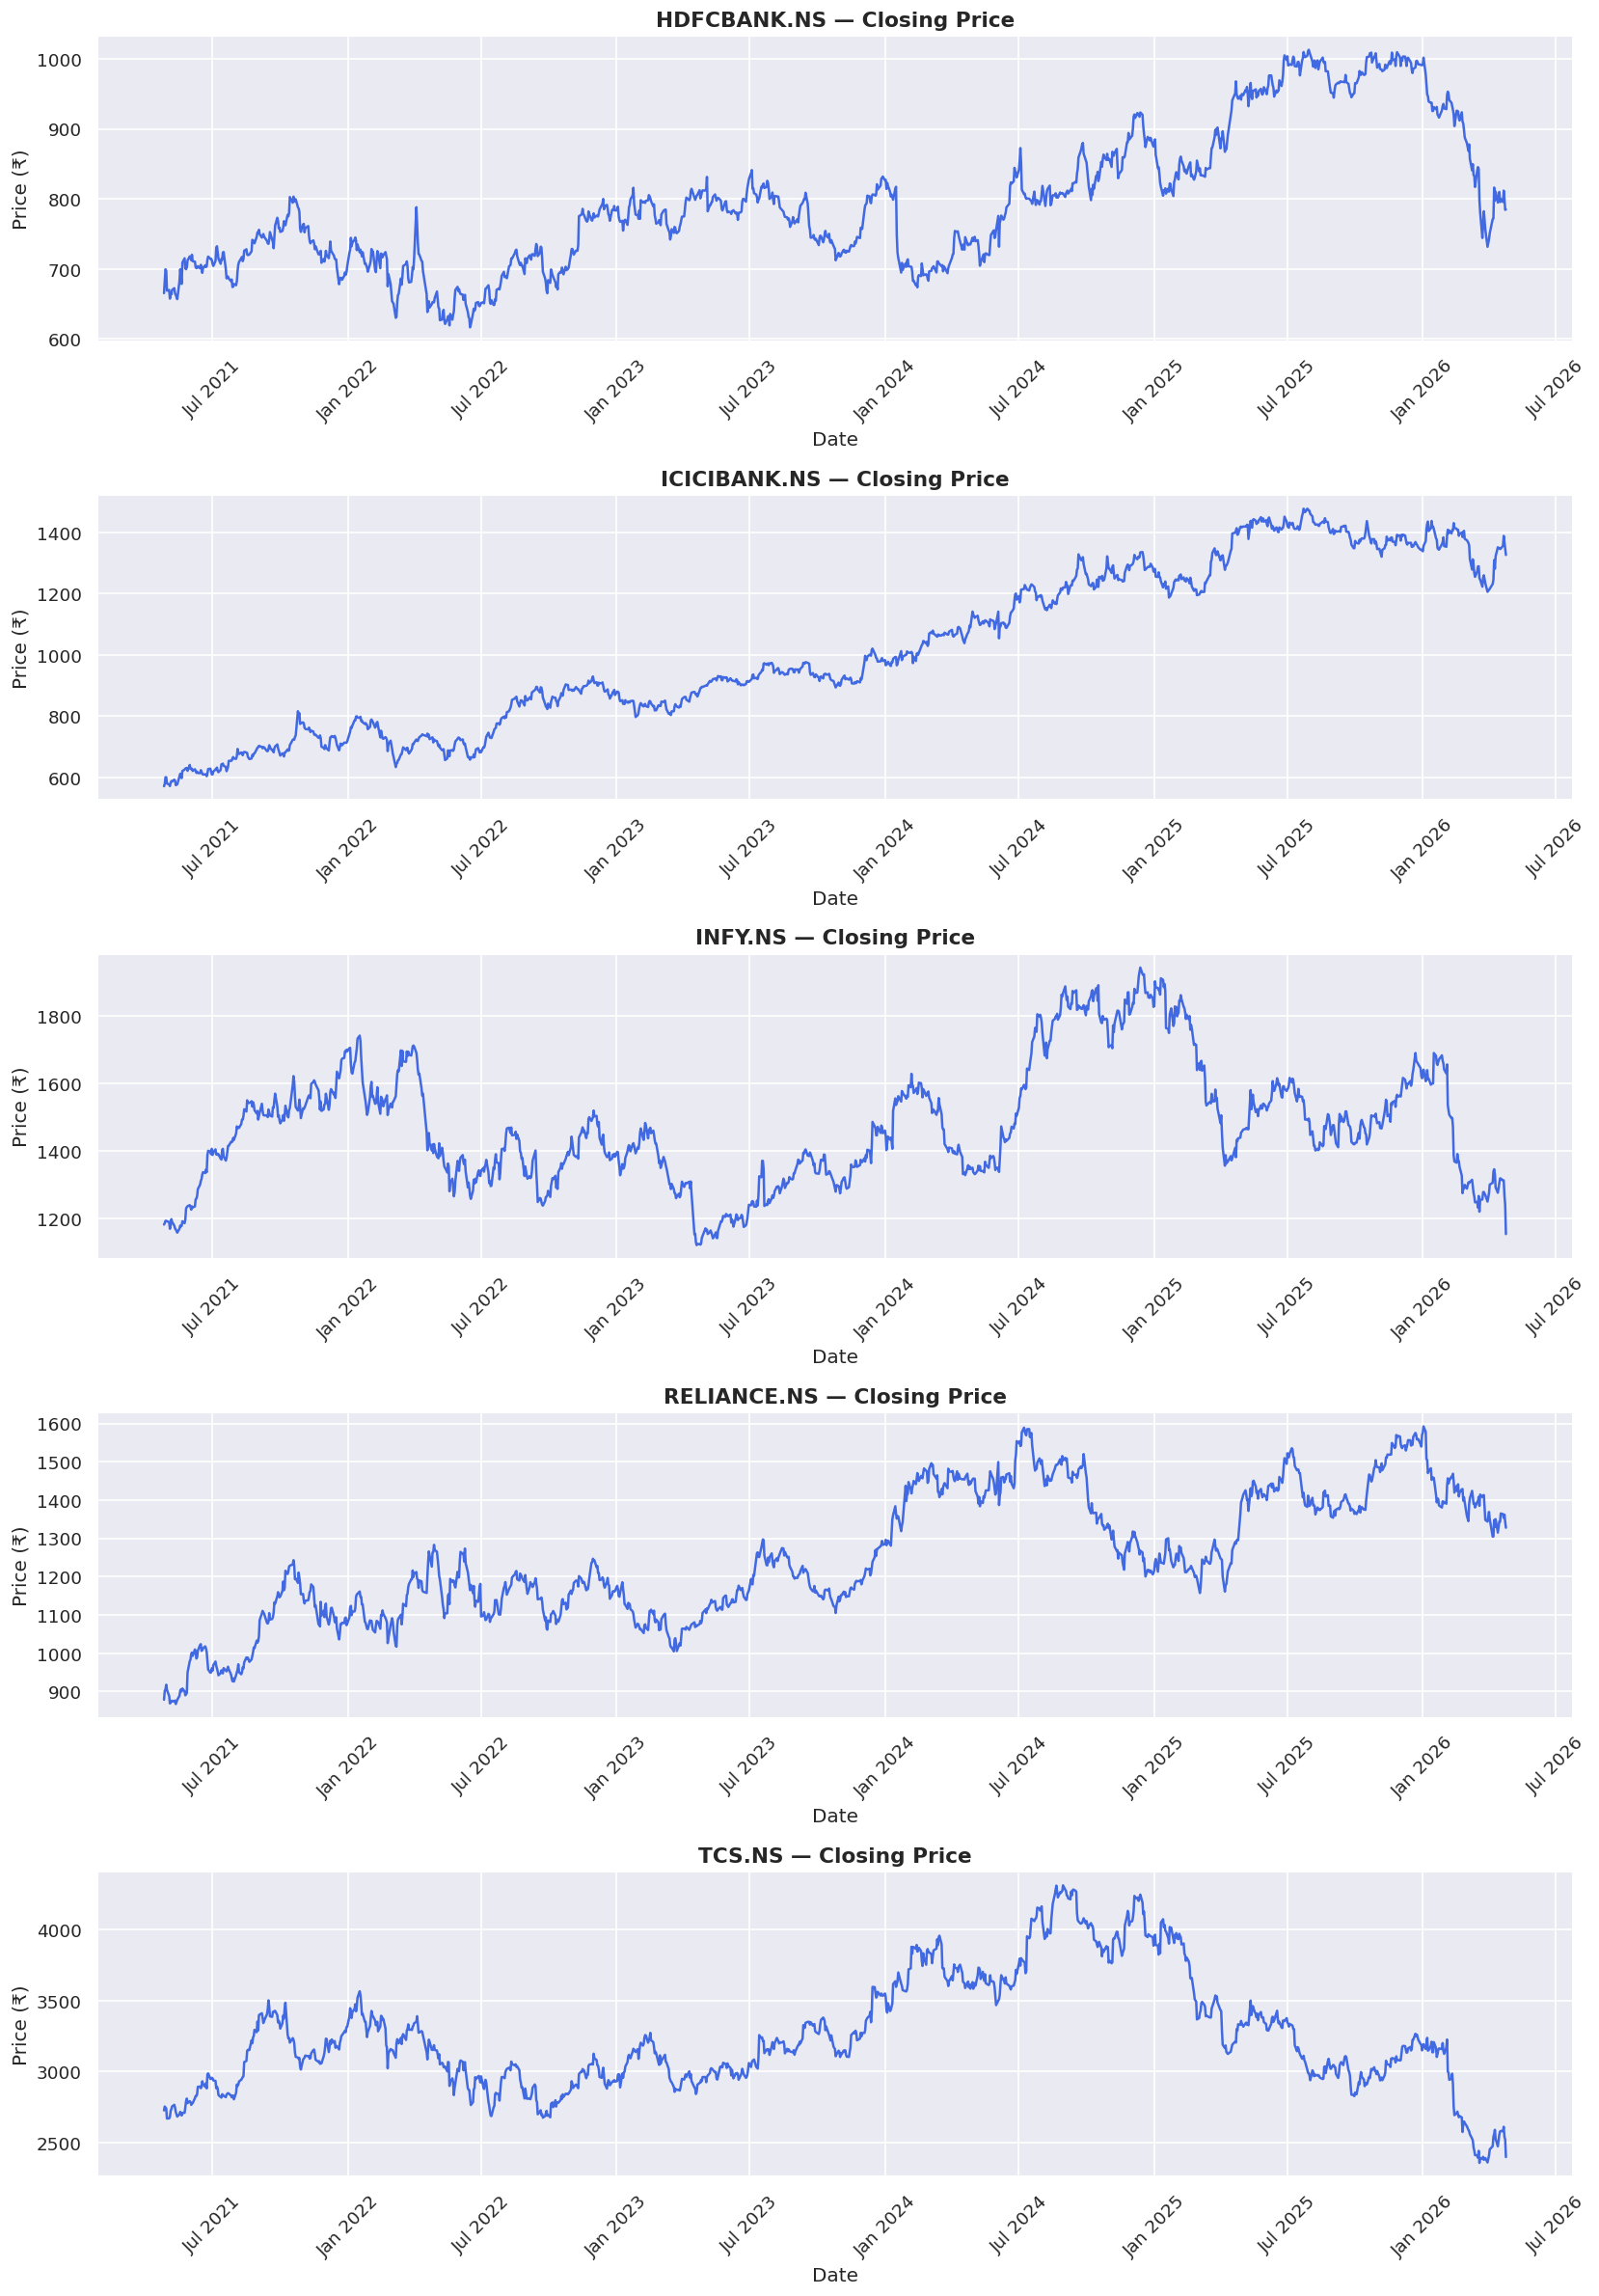

In [7]:
symbols = df["Symbol"].unique()
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 4 * len(symbols)), sharex=False)

for ax, symbol in zip(axes, symbols):
    data = df[df["Symbol"] == symbol]
    ax.plot(data["Date"], data["Close"], linewidth=1.5, color="royalblue")
    ax.set_title(f"{symbol} — Closing Price", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("trend_closing_price.png", bbox_inches="tight")
plt.show()

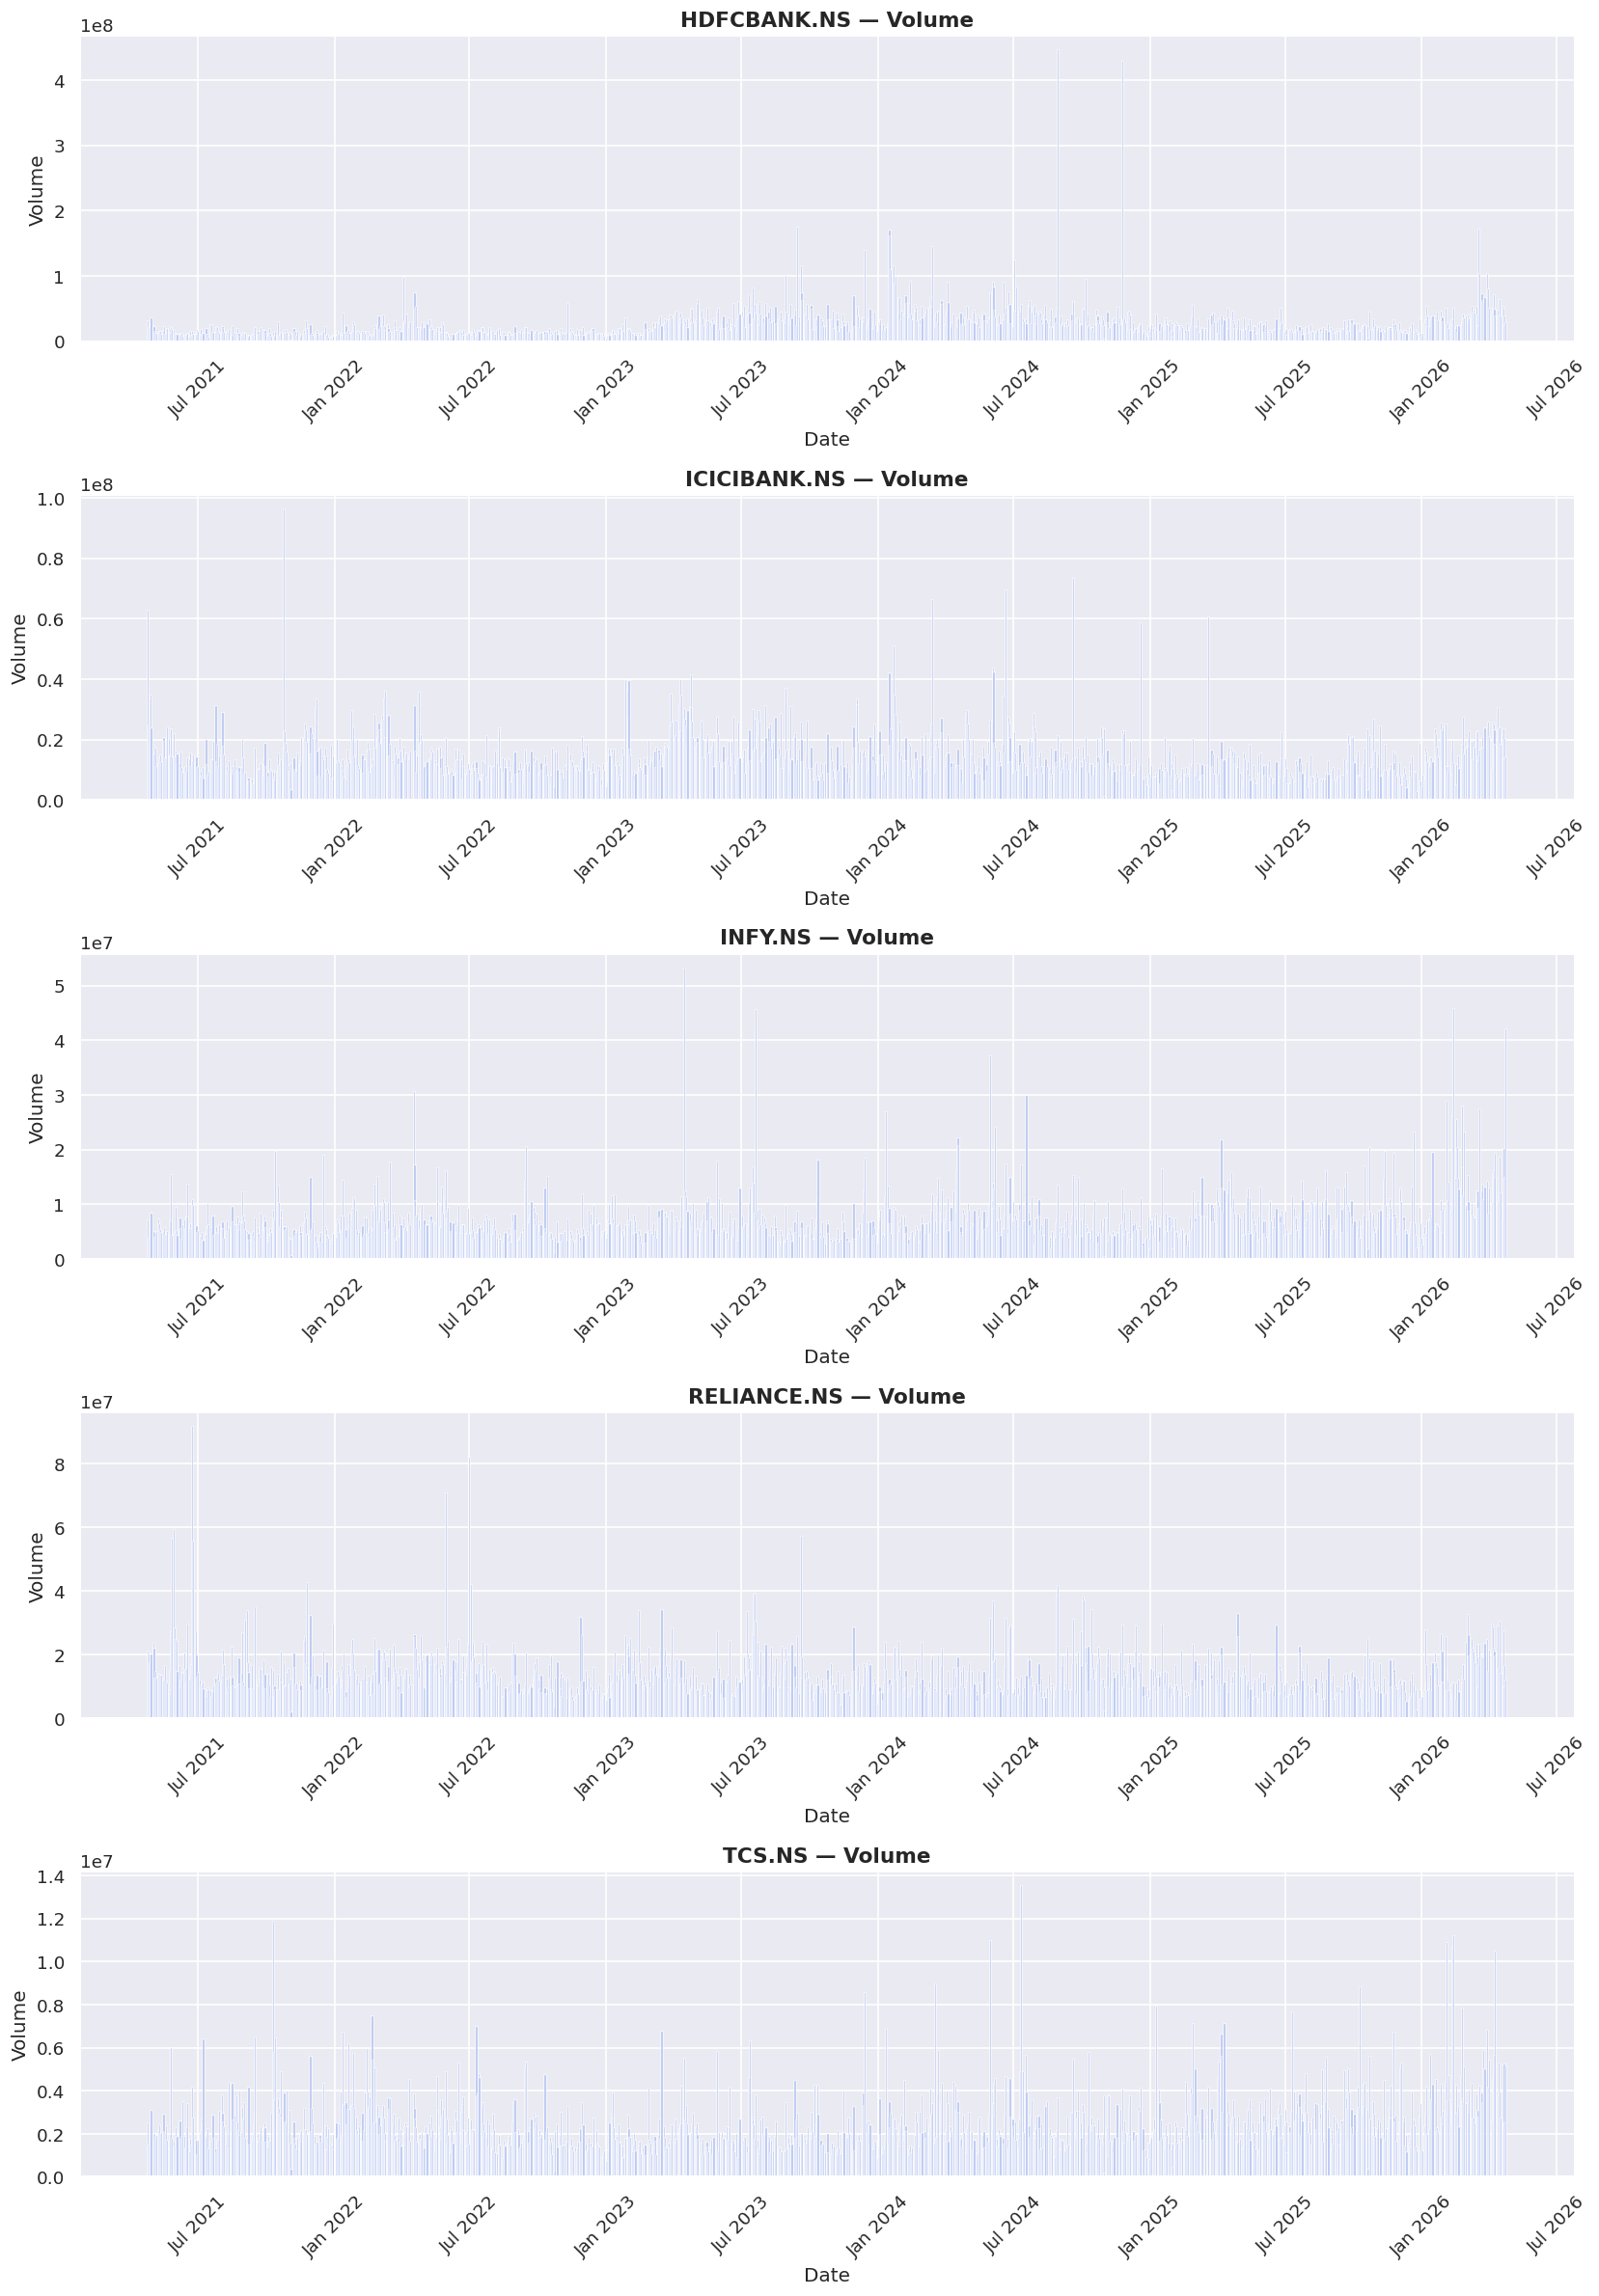

In [8]:
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 4 * len(symbols)), sharex=False)

for ax, symbol in zip(axes, symbols):
    data = df[df["Symbol"] == symbol]
    ax.bar(data["Date"], data["Volume"], color="royalblue", alpha=0.6, width=1.5)
    ax.set_title(f"{symbol} — Volume", fontsize=13, fontweight="bold")
    ax.set_ylabel("Volume")
    ax.set_xlabel("Date")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("trend_volume.png", bbox_inches="tight")
plt.show()

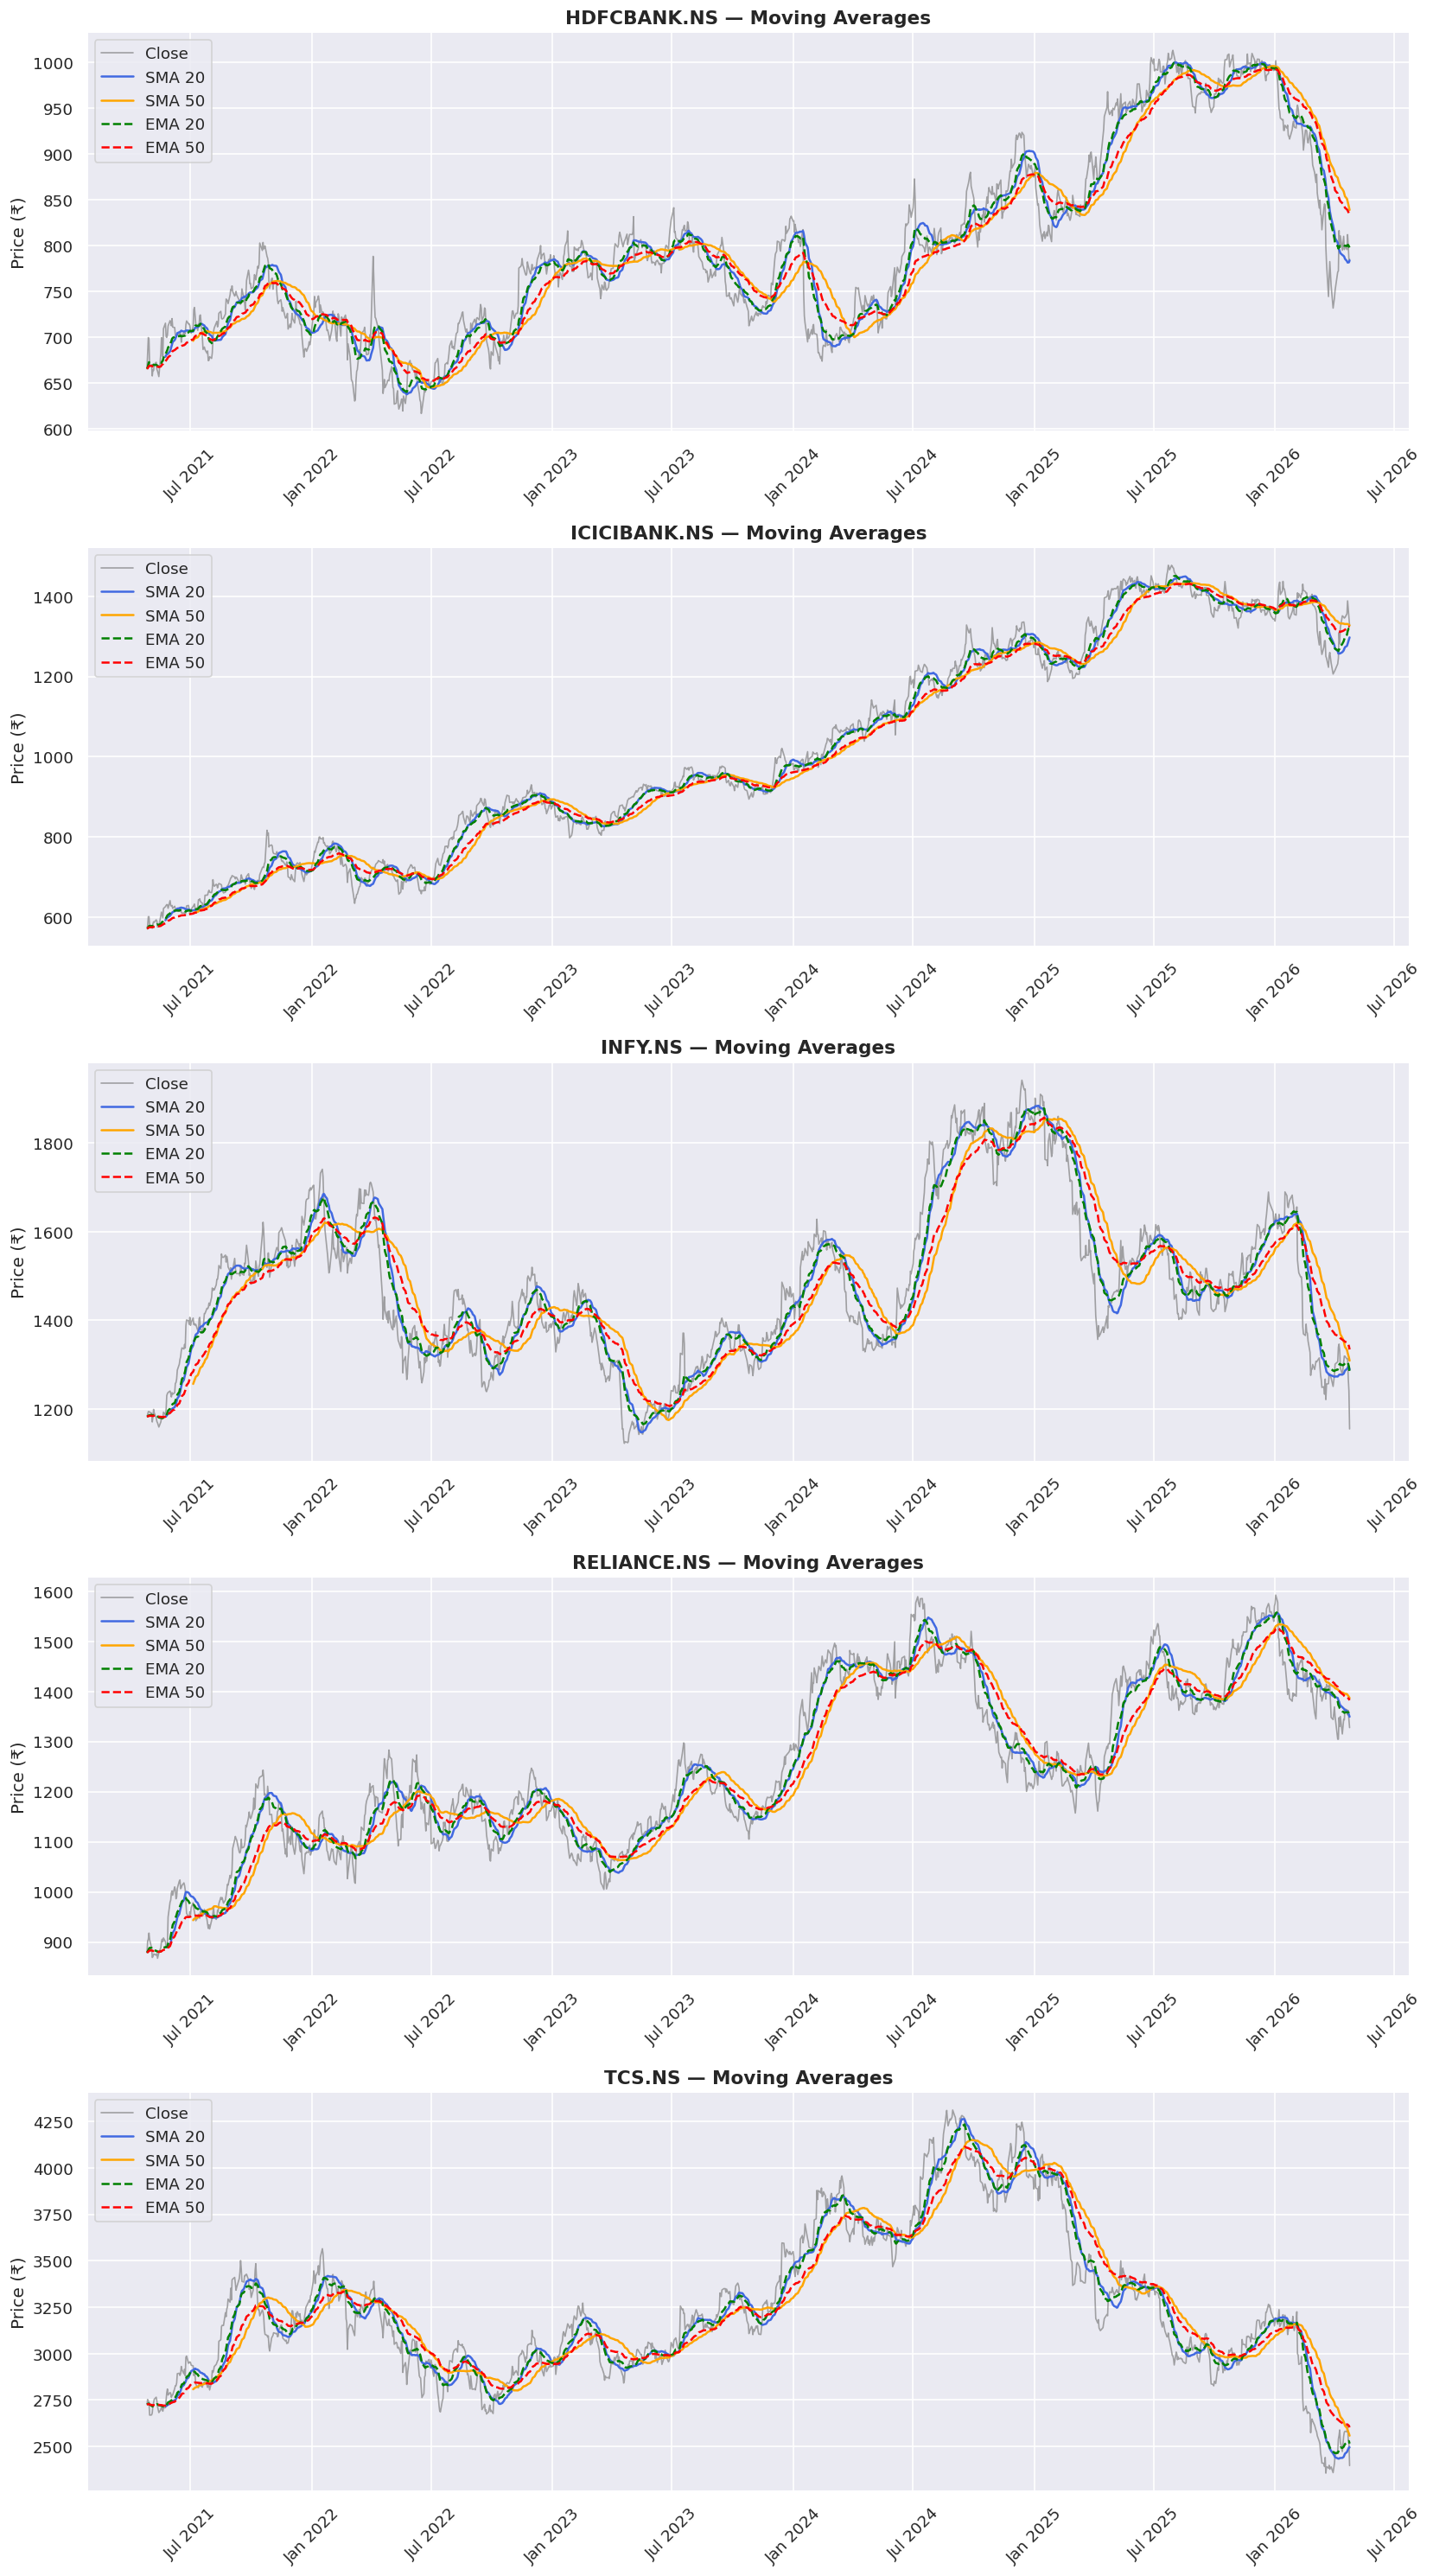

In [11]:
# Calculate indicators
for symbol in symbols:
    mask = df["Symbol"] == symbol
    df.loc[mask, "SMA_20"]  = df.loc[mask, "Close"].rolling(window=20).mean()
    df.loc[mask, "SMA_50"]  = df.loc[mask, "Close"].rolling(window=50).mean()
    df.loc[mask, "EMA_20"]  = df.loc[mask, "Close"].ewm(span=20, adjust=False).mean()
    df.loc[mask, "EMA_50"]  = df.loc[mask, "Close"].ewm(span=50, adjust=False).mean()

# Plot
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 5 * len(symbols)))

for ax, symbol in zip(axes, symbols):
    data = df[df["Symbol"] == symbol]
    ax.plot(data["Date"], data["Close"],  label="Close",  linewidth=1,   color="grey",      alpha=0.7)
    ax.plot(data["Date"], data["SMA_20"], label="SMA 20", linewidth=1.5, color="royalblue")
    ax.plot(data["Date"], data["SMA_50"], label="SMA 50", linewidth=1.5, color="orange")
    ax.plot(data["Date"], data["EMA_20"], label="EMA 20", linewidth=1.5, color="green",    linestyle="--")
    ax.plot(data["Date"], data["EMA_50"], label="EMA 50", linewidth=1.5, color="red",      linestyle="--")
    ax.set_title(f"{symbol} — Moving Averages", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("moving_averages.png", bbox_inches="tight")
plt.show()

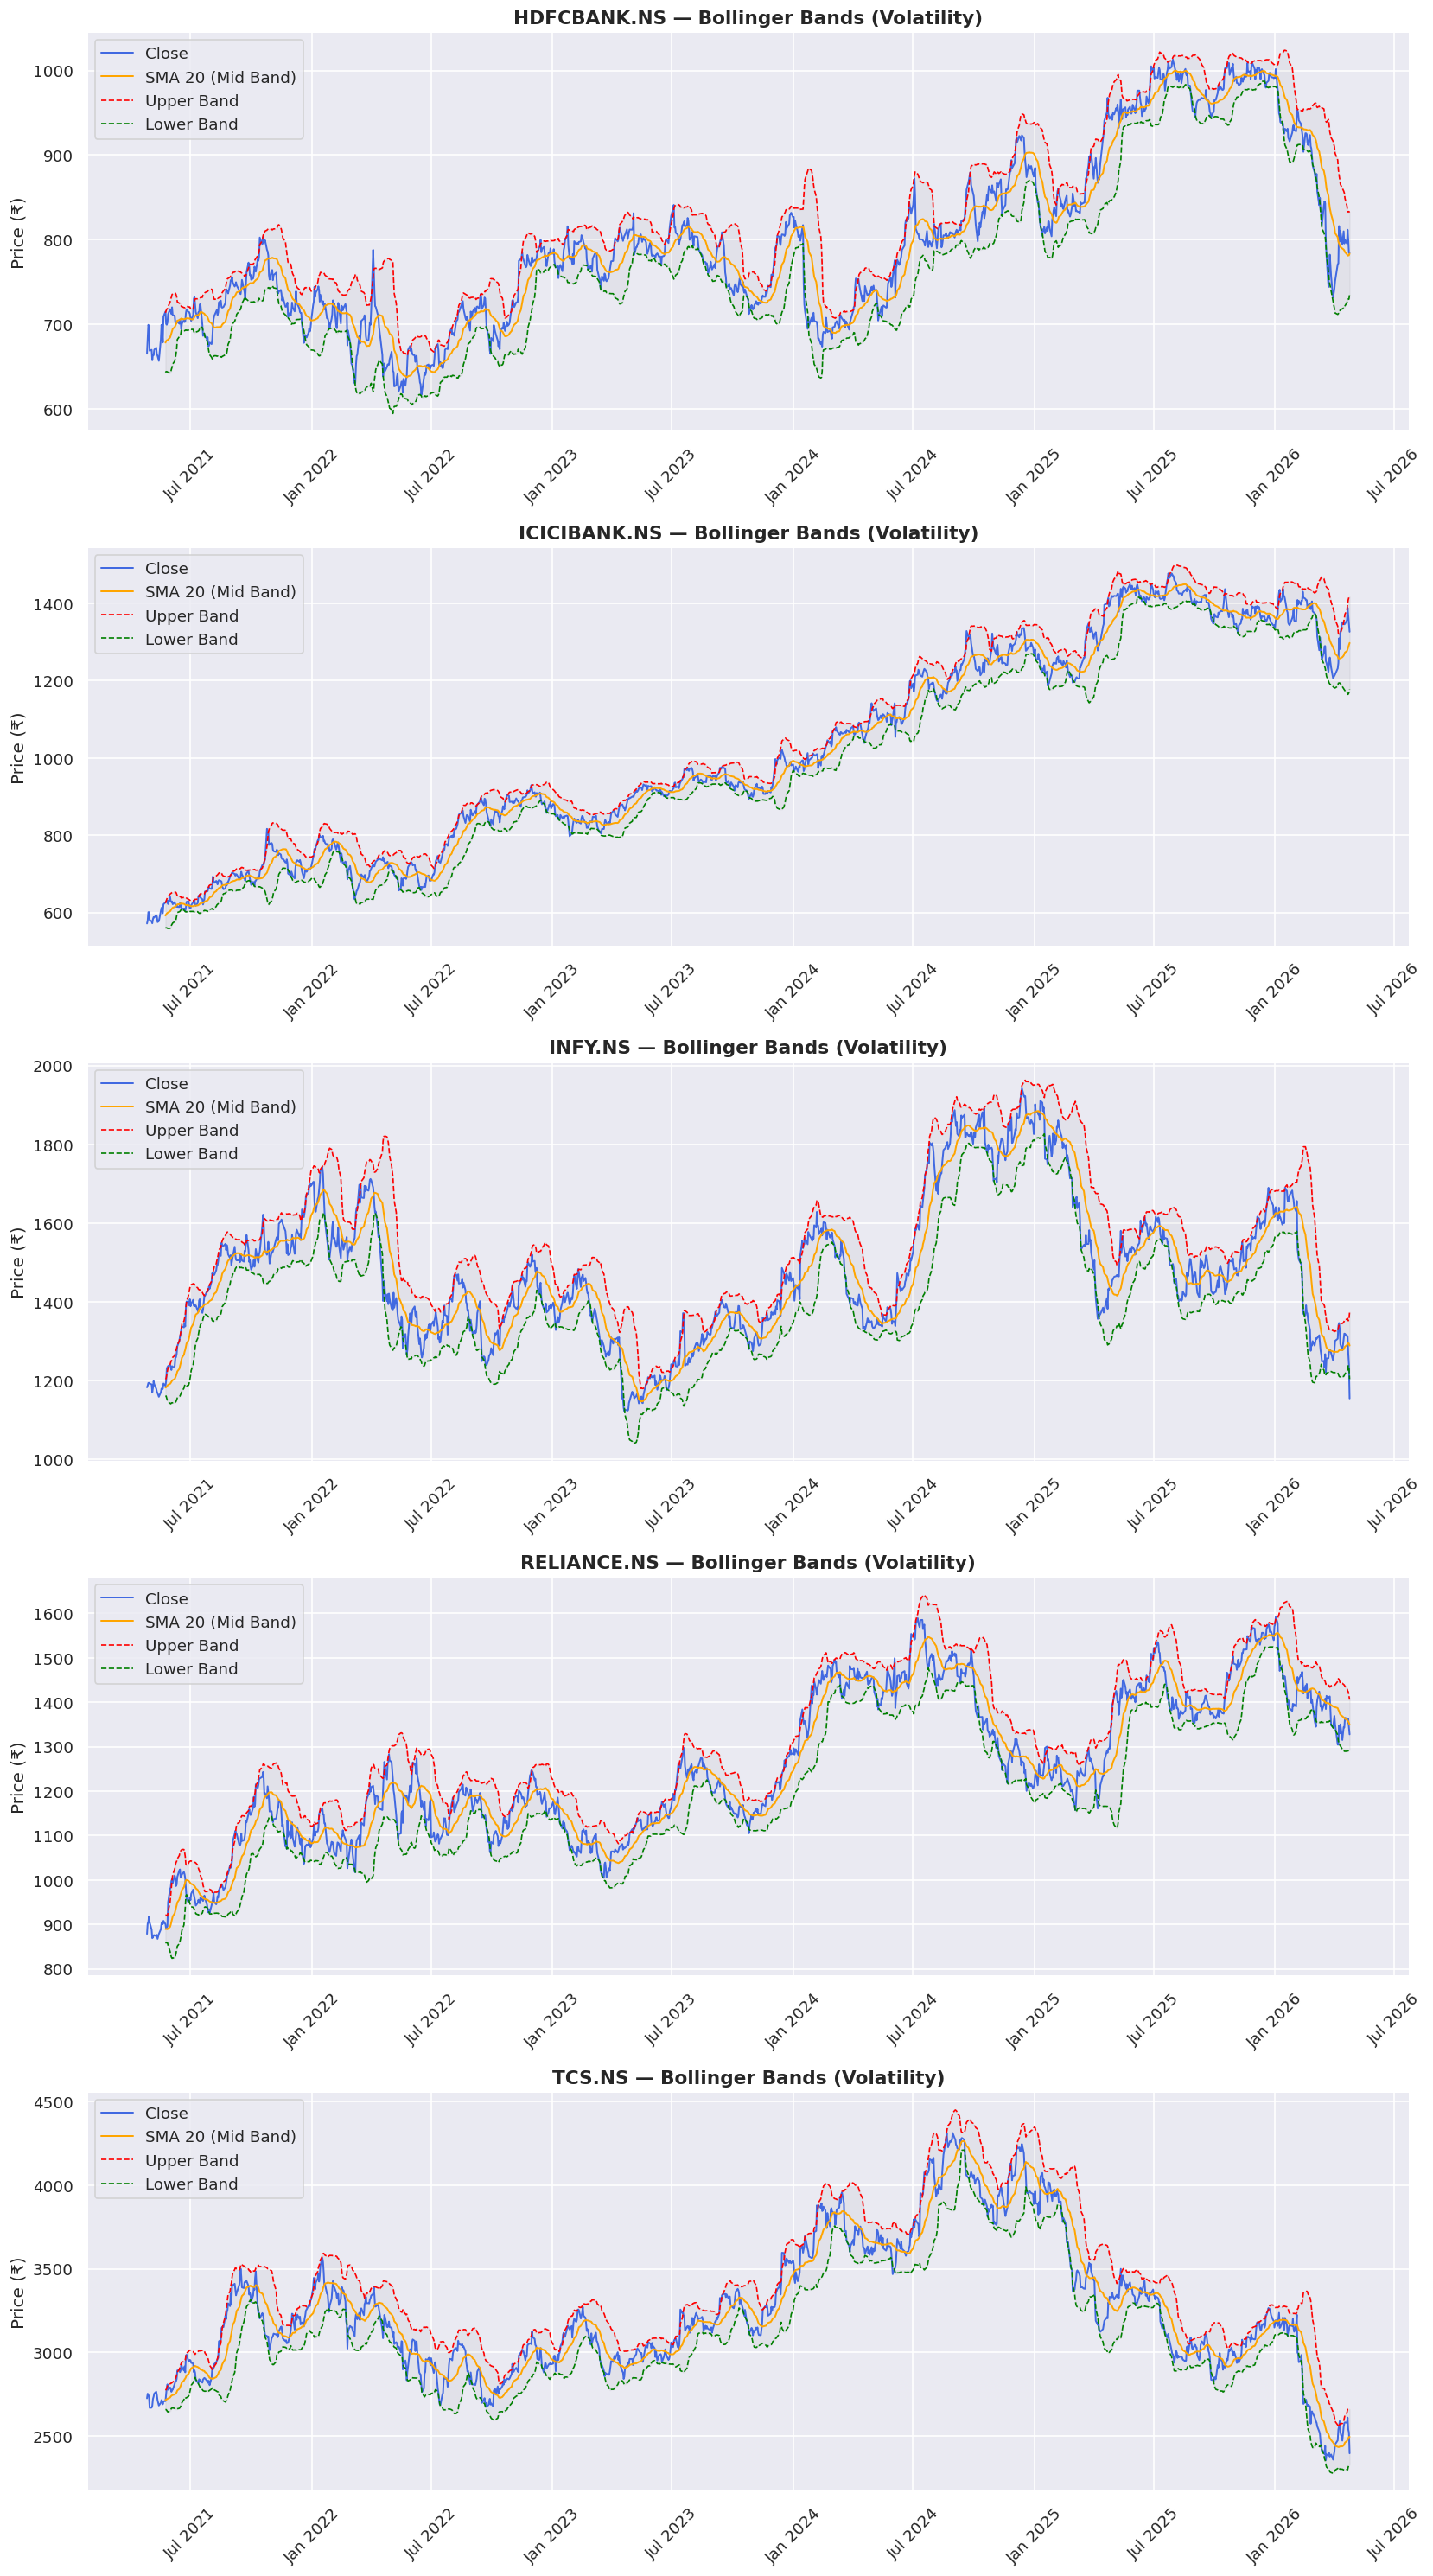

In [12]:
for symbol in symbols:
    mask = df["Symbol"] == symbol
    df.loc[mask, "Rolling_Std"] = df.loc[mask, "Close"].rolling(window=20).std()
    df.loc[mask, "BB_Upper"]    = df.loc[mask, "SMA_20"] + 2 * df.loc[mask, "Rolling_Std"]
    df.loc[mask, "BB_Lower"]    = df.loc[mask, "SMA_20"] - 2 * df.loc[mask, "Rolling_Std"]

fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 5 * len(symbols)))

for ax, symbol in zip(axes, symbols):
    data = df[df["Symbol"] == symbol]
    ax.plot(data["Date"], data["Close"],    label="Close",            color="royalblue", linewidth=1.2)
    ax.plot(data["Date"], data["SMA_20"],   label="SMA 20 (Mid Band)",color="orange",    linewidth=1.2)
    ax.plot(data["Date"], data["BB_Upper"], label="Upper Band",       color="red",       linewidth=1, linestyle="--")
    ax.plot(data["Date"], data["BB_Lower"], label="Lower Band",       color="green",     linewidth=1, linestyle="--")
    ax.fill_between(data["Date"], data["BB_Upper"], data["BB_Lower"], alpha=0.08, color="grey")
    ax.set_title(f"{symbol} — Bollinger Bands (Volatility)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("bollinger_bands.png", bbox_inches="tight")
plt.show()

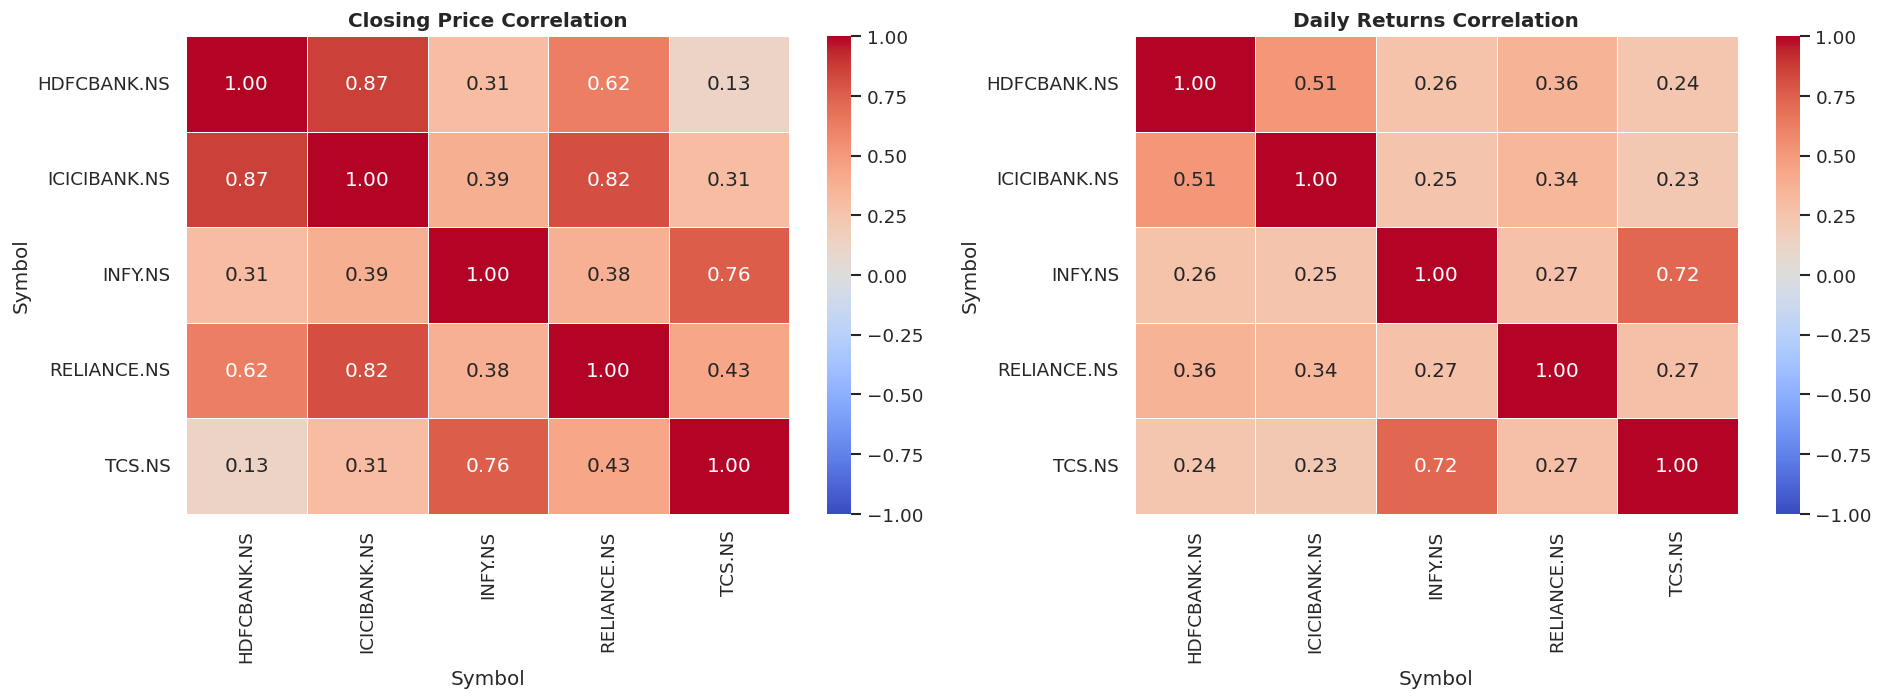

In [13]:
# Pivot to get Close price per symbol as columns
pivot = df.pivot_table(index="Date", columns="Symbol", values="Close")

# Daily returns correlation
returns = pivot.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap — price correlation
sns.heatmap(pivot.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Closing Price Correlation", fontweight="bold")

# Heatmap — returns correlation
sns.heatmap(returns.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Daily Returns Correlation", fontweight="bold")

plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [14]:
print("=" * 60)
print("📊 KEY INSIGHTS SUMMARY")
print("=" * 60)

for symbol in symbols:
    data = df[df["Symbol"] == symbol].copy()
    total_return = ((data["Close"].iloc[-1] - data["Close"].iloc[0]) / data["Close"].iloc[0]) * 100
    avg_vol      = data["Rolling_Std"].mean()
    max_price    = data["Close"].max()
    min_price    = data["Close"].min()

    print(f"\n📌 {symbol}")
    print(f"   Total Return     : {total_return:.2f}%")
    print(f"   Price Range      : ₹{min_price:.2f} → ₹{max_price:.2f}")
    print(f"   Avg Volatility   : {avg_vol:.2f}")

    # Trend signal based on last SMA crossover
    last = data.dropna(subset=["SMA_20", "SMA_50"]).iloc[-1]
    signal = "🟢 Bullish (SMA20 > SMA50)" if last["SMA_20"] > last["SMA_50"] else "🔴 Bearish (SMA20 < SMA50)"
    print(f"   Current Signal   : {signal}")

print("\n" + "=" * 60)

📊 KEY INSIGHTS SUMMARY

📌 HDFCBANK.NS
   Total Return     : 17.97%
   Price Range      : ₹616.52 → ₹1012.90
   Avg Volatility   : 16.72
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)

📌 ICICIBANK.NS
   Total Return     : 131.97%
   Price Range      : ₹571.70 → ₹1477.20
   Avg Volatility   : 21.01
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)

📌 INFY.NS
   Total Return     : -2.38%
   Price Range      : ₹1122.01 → ₹1942.22
   Avg Volatility   : 39.50
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)

📌 RELIANCE.NS
   Total Return     : 51.11%
   Price Range      : ₹867.48 → ₹1592.30
   Avg Volatility   : 29.54
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)

📌 TCS.NS
   Total Return     : -12.07%
   Price Range      : ₹2356.00 → ₹4311.59
   Avg Volatility   : 74.81
   Current Signal   : 🔴 Bearish (SMA20 < SMA50)



In [15]:
df.head()

,Date,Close,High,Low,Open,Volume,Symbol,SMA_20,SMA_50,EMA_20,EMA_50,Rolling_Std,BB_Upper,BB_Lower
0,2021-04-26,665.296143,676.756944,664.325264,669.179539,30170952,HDFCBANK.NS,NaN,NaN,665.296143,665.296143,NaN,NaN,NaN
1,2021-04-27,681.350769,682.913632,665.296188,666.456455,20592906,HDFCBANK.NS,NaN,NaN,666.825155,665.925736,NaN,NaN,NaN
2,2021-04-28,699.394531,700.436401,677.704185,680.190522,24103940,HDFCBANK.NS,NaN,NaN,669.927000,667.238238,NaN,NaN,NaN
3,2021-04-29,697.358093,712.110366,691.911833,703.846224,24078552,HDFCBANK.NS,NaN,NaN,672.539485,668.419408,NaN,NaN,NaN
4,2021-04-30,668.848145,688.502040,666.574900,684.334444,35232902,HDFCBANK.NS,NaN,NaN,672.187929,668.436222,NaN,NaN,NaN


In [35]:
!pip install xgboost -q

import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [40]:
def create_features(data):
    df_feat = data.copy()

    # ✅ Fix — reset index so Date becomes a column
    if df_feat.index.name == "Date":
        df_feat.reset_index(inplace=True)

    # Lag features
    df_feat["Lag_1"]  = df_feat["Close"].shift(1)
    df_feat["Lag_2"]  = df_feat["Close"].shift(2)
    df_feat["Lag_3"]  = df_feat["Close"].shift(3)
    df_feat["Lag_5"]  = df_feat["Close"].shift(5)
    df_feat["Lag_10"] = df_feat["Close"].shift(10)

    # Price-based features
    df_feat["Daily_Return"]   = df_feat["Close"].pct_change()
    df_feat["High_Low_Range"] = df_feat["High"] - df_feat["Low"]
    df_feat["Open_Close_Gap"] = df_feat["Close"] - df_feat["Open"]

    # Volume feature
    df_feat["Volume_MA_10"] = df_feat["Volume"].rolling(window=10).mean()

    df_feat.dropna(inplace=True)

    return df_feat


all_featured = []
for symbol in df["Symbol"].unique():
    stock_data = df[df["Symbol"] == symbol].copy()

    # ✅ Ensure Date is a column not index
    if stock_data.index.name == "Date":
        stock_data.reset_index(inplace=True)

    featured = create_features(stock_data)
    all_featured.append(featured)

df_featured = pd.concat(all_featured, ignore_index=True)

# ✅ Final safety check
if "Date" not in df_featured.columns:
    df_featured.reset_index(inplace=True)

print(f"✅ Features created — {df_featured.shape[0]} rows, {df_featured.shape[1]} columns")
print("Columns:", df_featured.columns.tolist())

✅ Features created — 5940 rows, 23 columns
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50', 'Rolling_Std', 'BB_Upper', 'BB_Lower', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10', 'Daily_Return', 'High_Low_Range', 'Open_Close_Gap', 'Volume_MA_10']


In [41]:
FEATURES = [
    "Lag_1", "Lag_2", "Lag_3", "Lag_5", "Lag_10",
    "SMA_20", "SMA_50",
    "EMA_20", "EMA_50",
    "BB_Upper", "BB_Lower", "Rolling_Std",
    "Daily_Return", "High_Low_Range", "Open_Close_Gap",
    "Volume", "Volume_MA_10"
]

TARGET = "Close"  # predicting next day's closing price

print(f"✅ Features: {len(FEATURES)}")
print(f"✅ Target  : {TARGET}")

✅ Features: 17
✅ Target  : Close


In [42]:
TRAIN_RATIO = 0.80
xgb_results = {}  # store results per stock

for symbol in df_featured["Symbol"].unique():
    print(f"\n📈 Training XGBoost for {symbol}...")

    data = df_featured[df_featured["Symbol"] == symbol].copy()
    data = data.sort_values("Date").reset_index(drop=True)

    X = data[FEATURES]
    y = data[TARGET]

    # Time-ordered split — no shuffling
    split_idx = int(len(data) * TRAIN_RATIO)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f"   Train: {len(X_train)} rows | Test: {len(X_test)} rows")

    # Scale features
    scaler  = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Train
    model = XGBRegressor(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 5,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        random_state      = 42,
        verbosity         = 0
    )
    model.fit(
        X_train_scaled, y_train,
        eval_set              = [(X_test_scaled, y_test)],
        verbose               = False
    )

    # Predict
    preds  = model.predict(X_test_scaled)
    actual = y_test.values

    # Metrics
    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae  = mean_absolute_error(actual, preds)
    mape = np.mean(np.abs((actual - preds) / actual)) * 100

    xgb_results[symbol] = {
        "model"       : model,
        "scaler"      : scaler,
        "test_dates"  : data["Date"].iloc[split_idx:].values,
        "actual"      : actual,
        "predicted"   : preds,
        "rmse"        : rmse,
        "mae"         : mae,
        "mape"        : mape
    }

    print(f"   ✅ RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}%")


📈 Training XGBoost for HDFCBANK.NS...
   Train: 950 rows | Test: 238 rows
   ✅ RMSE: 41.33 | MAE: 33.50 | MAPE: 3.41%

📈 Training XGBoost for ICICIBANK.NS...
   Train: 950 rows | Test: 238 rows
   ✅ RMSE: 27.36 | MAE: 22.23 | MAPE: 1.60%

📈 Training XGBoost for INFY.NS...
   Train: 950 rows | Test: 238 rows
   ✅ RMSE: 10.12 | MAE: 6.59 | MAPE: 0.45%

📈 Training XGBoost for RELIANCE.NS...
   Train: 950 rows | Test: 238 rows
   ✅ RMSE: 15.43 | MAE: 11.39 | MAPE: 0.78%

📈 Training XGBoost for TCS.NS...
   Train: 950 rows | Test: 238 rows
   ✅ RMSE: 97.58 | MAE: 43.42 | MAPE: 1.71%


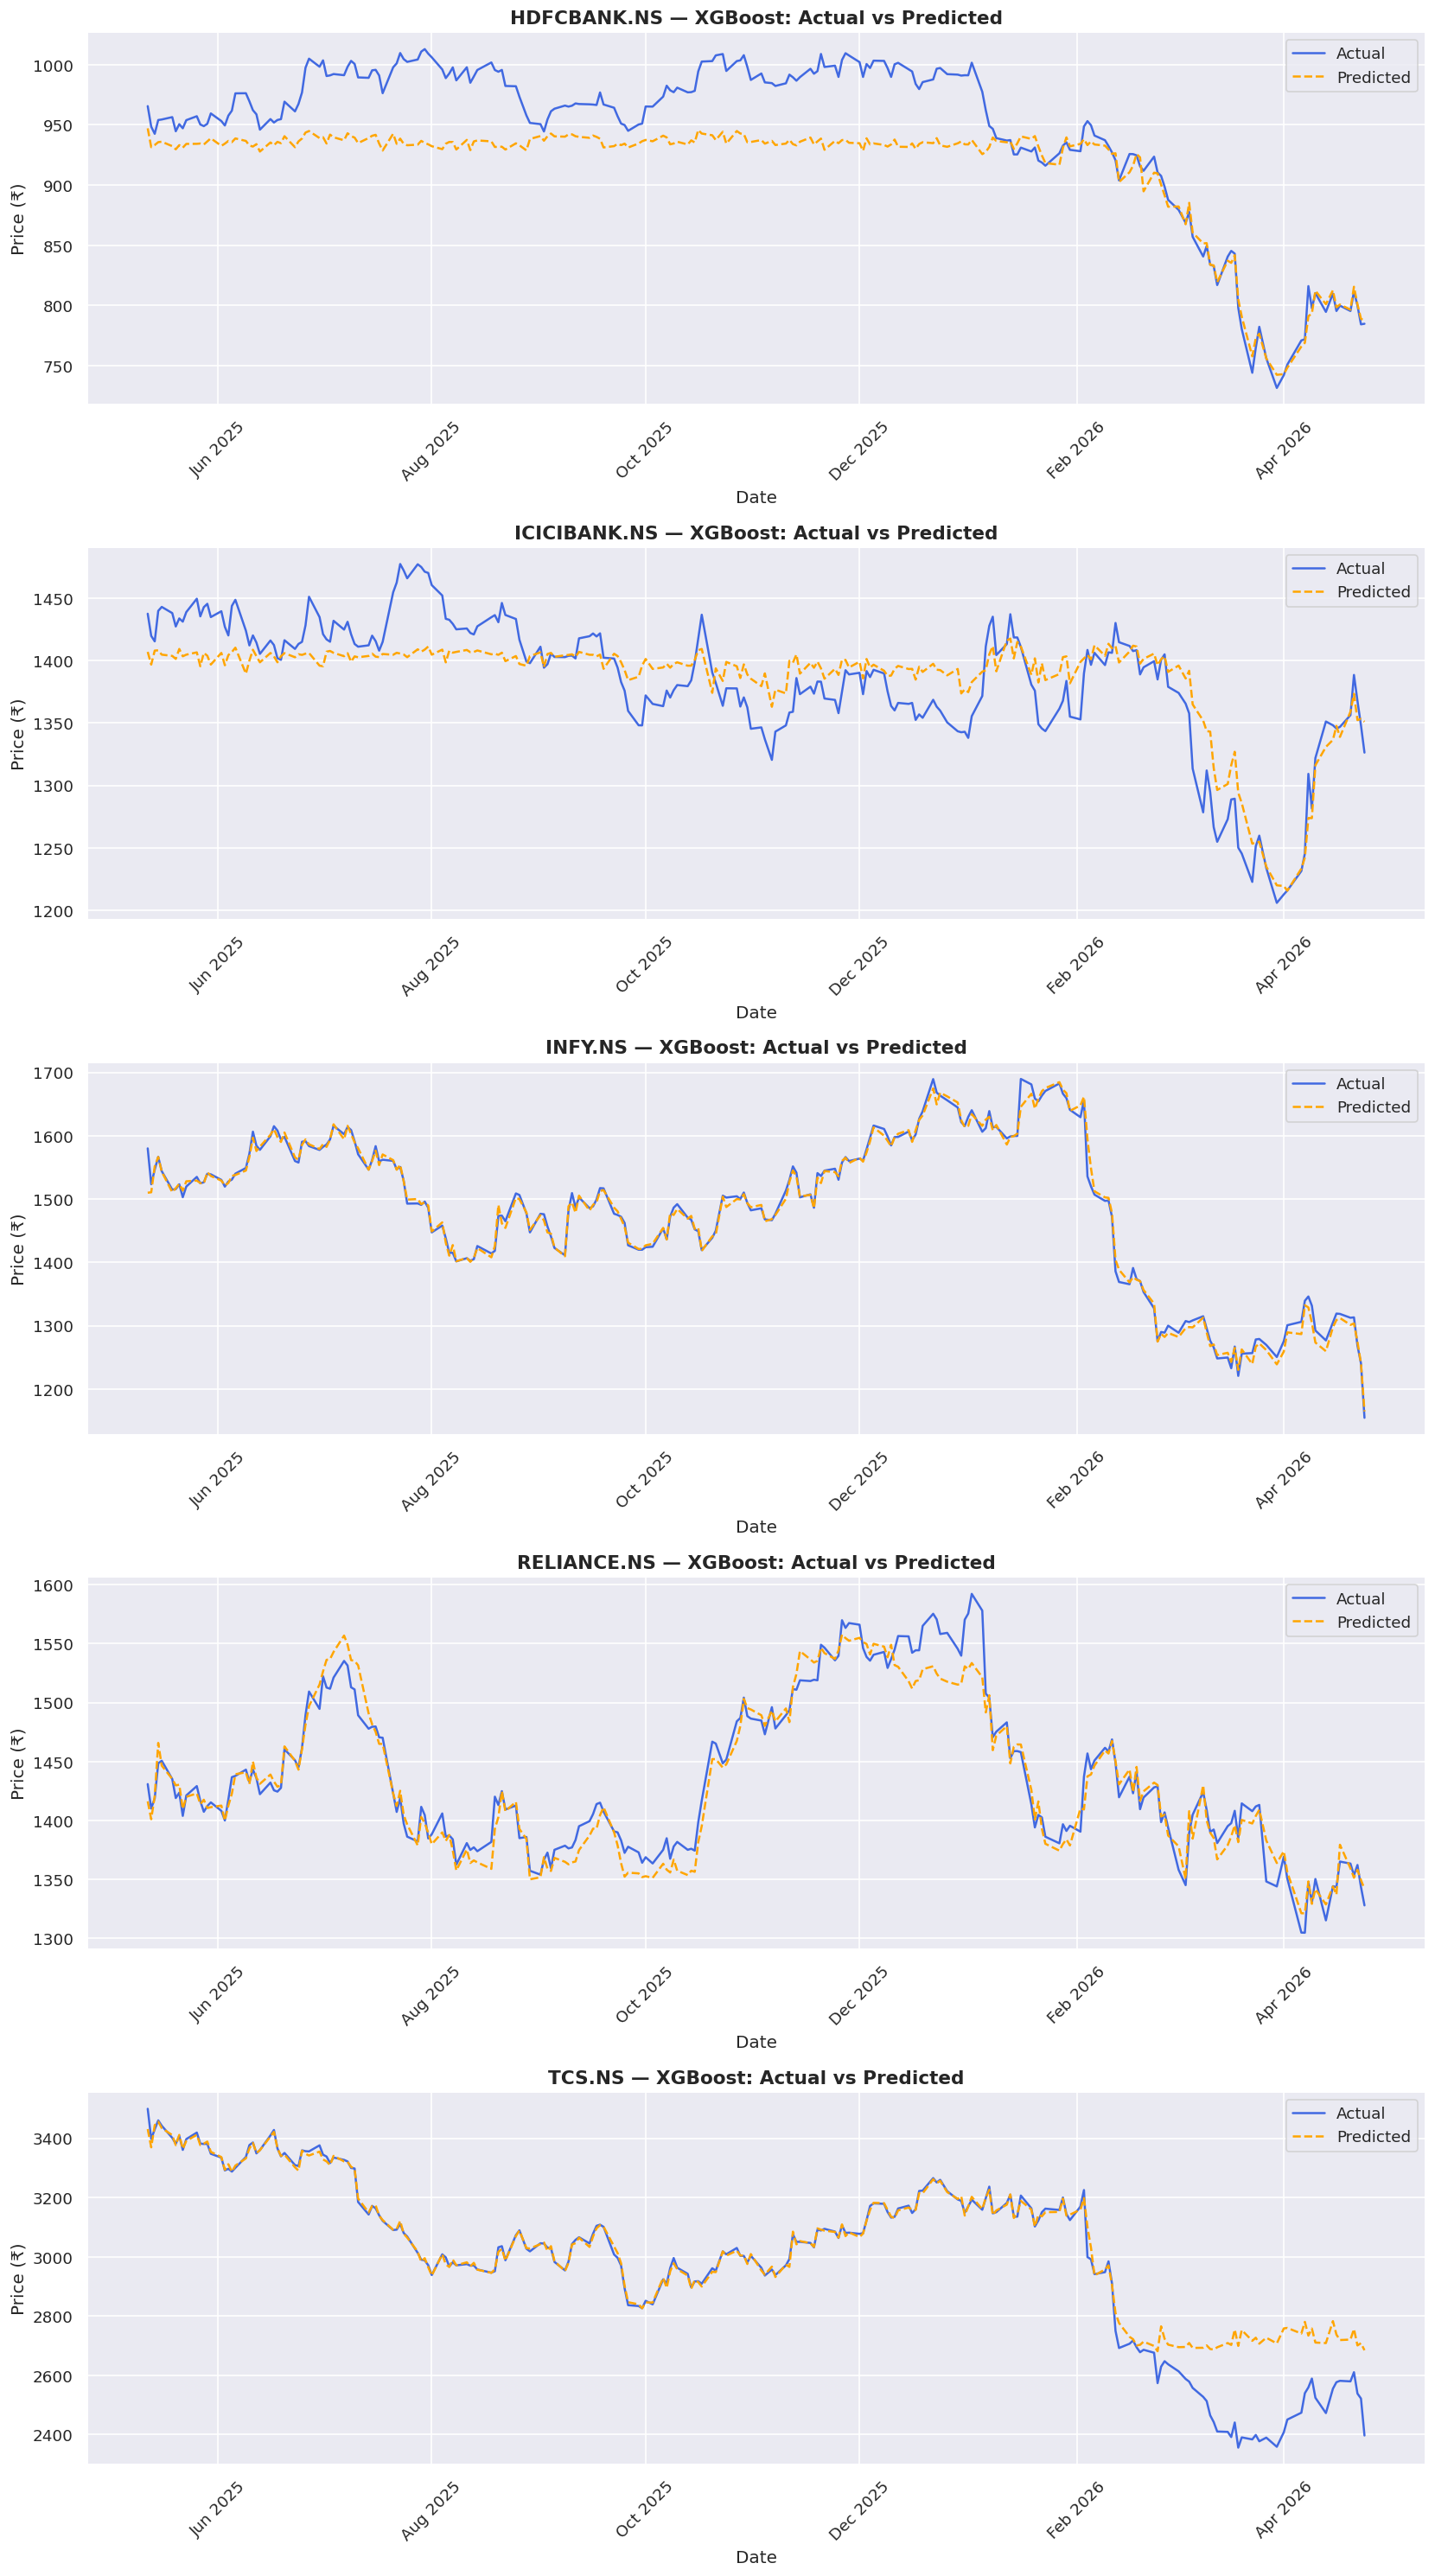

In [43]:
symbols = list(xgb_results.keys())
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 5 * len(symbols)))

if len(symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols):
    res = xgb_results[symbol]
    ax.plot(res["test_dates"], res["actual"],    label="Actual",    color="royalblue", linewidth=1.5)
    ax.plot(res["test_dates"], res["predicted"], label="Predicted", color="orange",    linewidth=1.5, linestyle="--")
    ax.set_title(f"{symbol} — XGBoost: Actual vs Predicted", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.set_xlabel("Date")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("xgb_predictions.png", bbox_inches="tight")
plt.show()

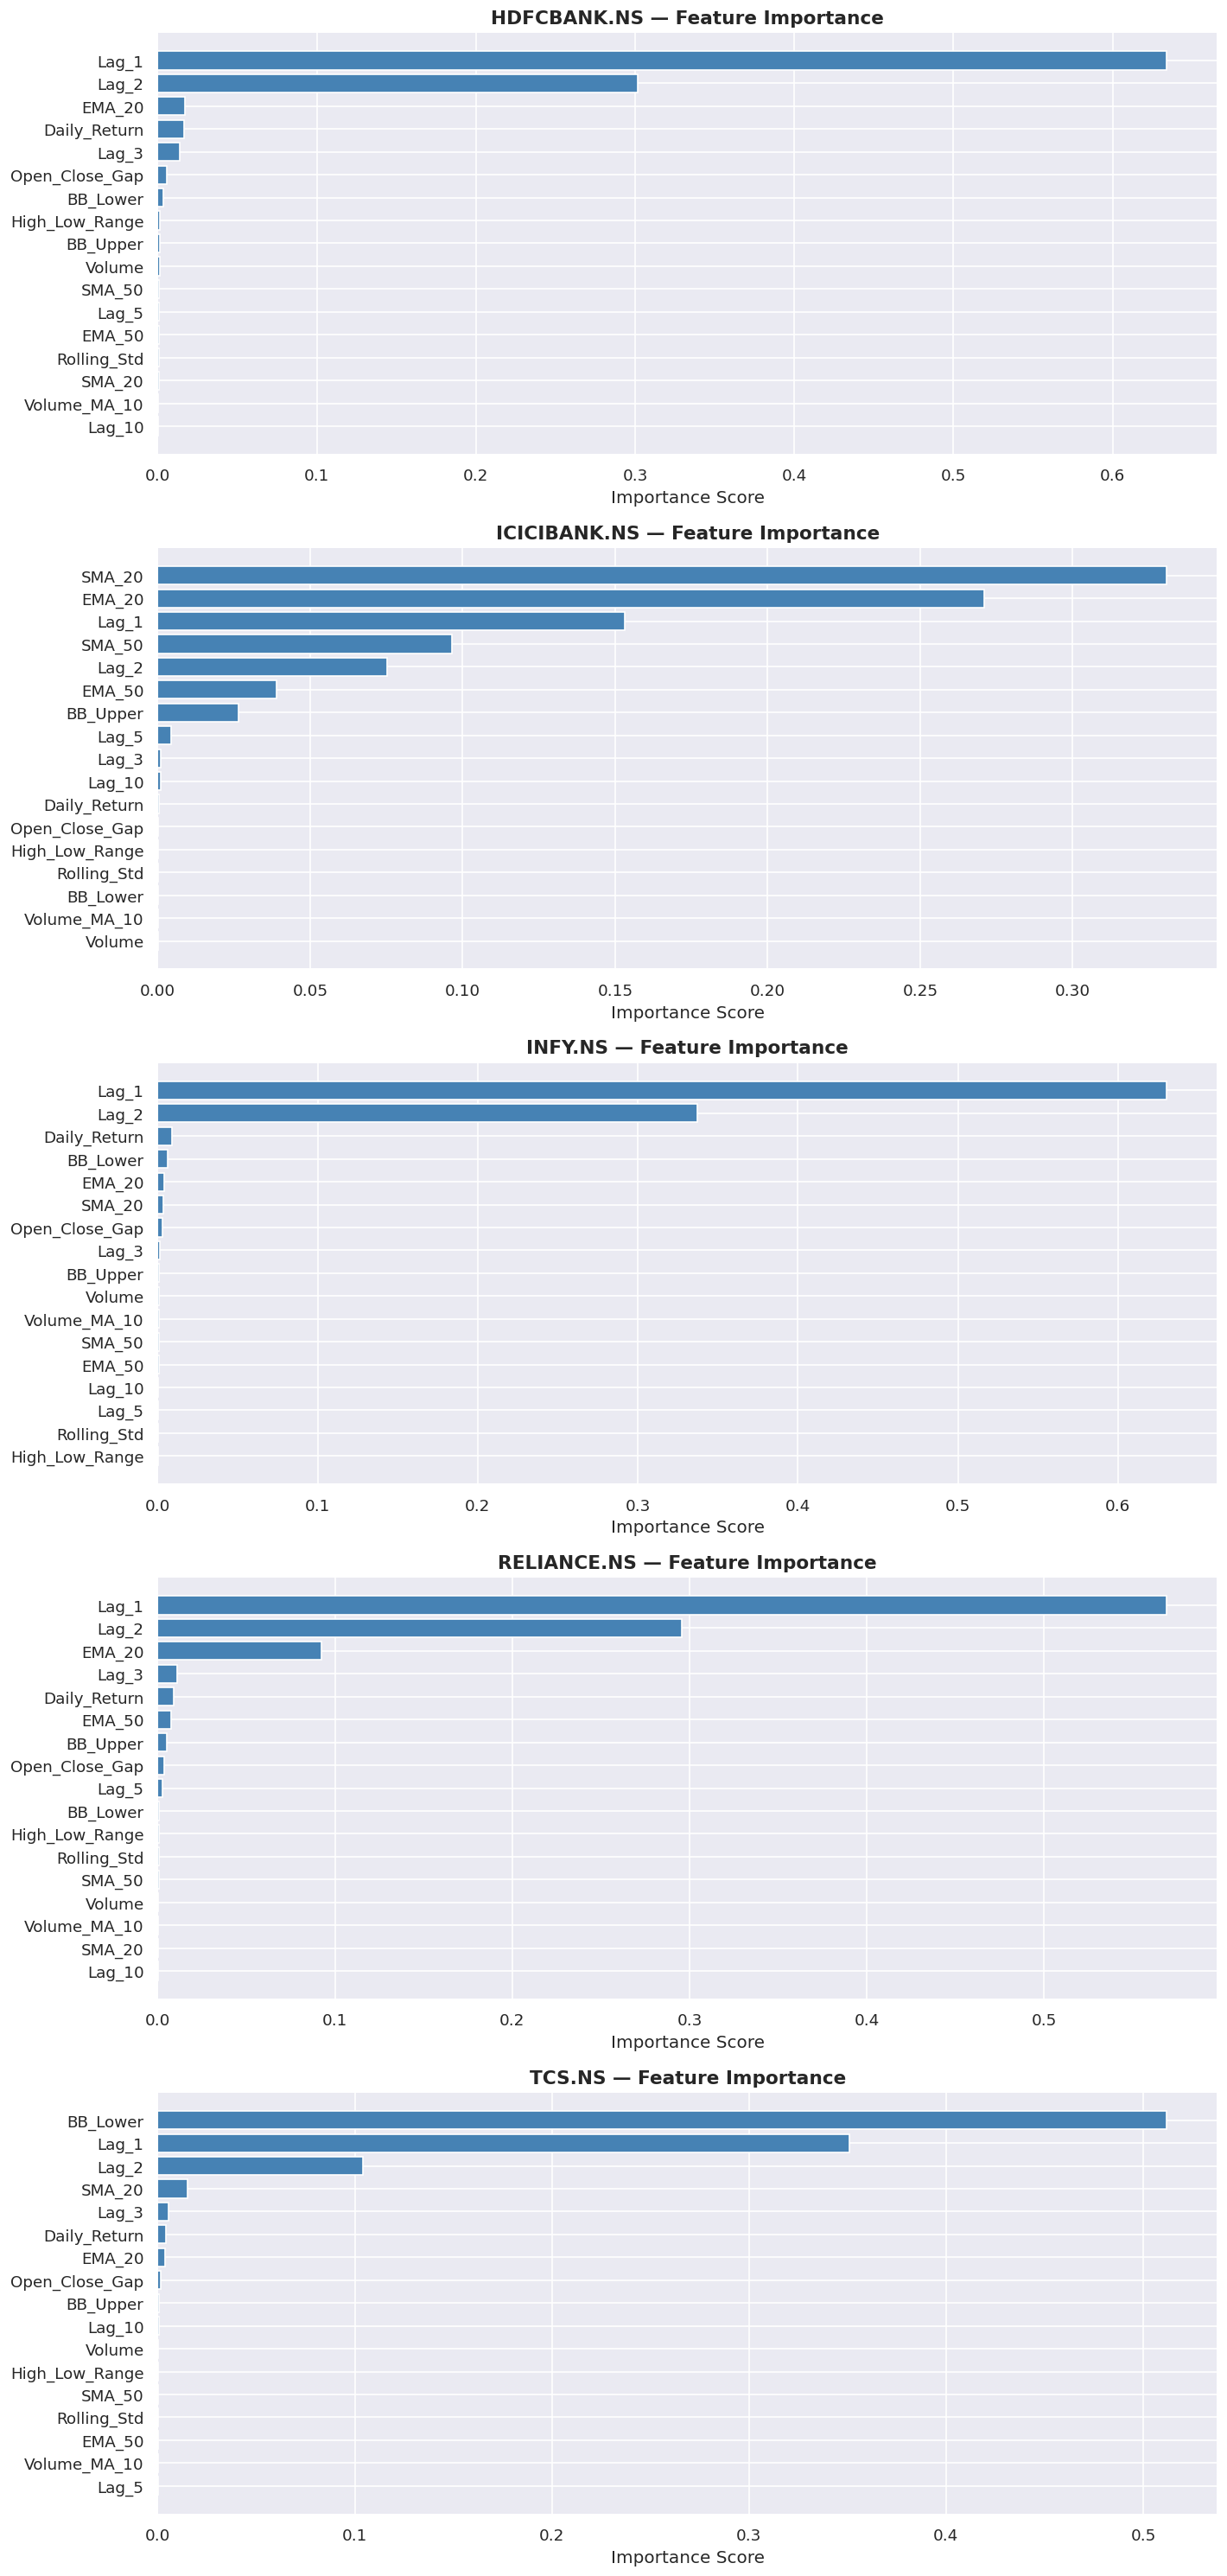

In [44]:
fig, axes = plt.subplots(len(symbols), 1, figsize=(12, 5 * len(symbols)))

if len(symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, symbols):
    model = xgb_results[symbol]["model"]

    importance_df = pd.DataFrame({
        "Feature"    : FEATURES,
        "Importance" : model.feature_importances_
    }).sort_values("Importance", ascending=True)

    ax.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
    ax.set_title(f"{symbol} — Feature Importance", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("xgb_feature_importance.png", bbox_inches="tight")
plt.show()

In [45]:
print("\n" + "=" * 60)
print("📊 XGBOOST MODEL PERFORMANCE SUMMARY")
print("=" * 60)

summary = []
for symbol, res in xgb_results.items():
    summary.append({
        "Symbol" : symbol,
        "RMSE"   : round(res["rmse"], 2),
        "MAE"    : round(res["mae"],  2),
        "MAPE %" : round(res["mape"], 2)
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df.to_csv("xgb_metrics.csv", index=False)
print("\n✅ Metrics saved to xgb_metrics.csv")


📊 XGBOOST MODEL PERFORMANCE SUMMARY
      Symbol  RMSE   MAE  MAPE %
 HDFCBANK.NS 41.33 33.50    3.41
ICICIBANK.NS 27.36 22.23    1.60
     INFY.NS 10.12  6.59    0.45
 RELIANCE.NS 15.43 11.39    0.78
      TCS.NS 97.58 43.42    1.71

✅ Metrics saved to xgb_metrics.csv


In [48]:
# Cell 16 — Predict Future Prices

FUTURE_DAYS = 10  # how many days ahead to predict

future_results = {}

for symbol in df_featured["Symbol"].unique():
    print(f"\n🔮 Predicting next {FUTURE_DAYS} days for {symbol}...")

    data   = df_featured[df_featured["Symbol"] == symbol].copy()
    data   = data.sort_values("Date").reset_index(drop=True)

    model  = xgb_results[symbol]["model"]
    scaler = xgb_results[symbol]["scaler"]

    # Start from the last known row
    last_row = data.iloc[-1].copy()
    future_preds = []
    future_dates = []

    last_date = pd.to_datetime(data["Date"].iloc[-1])

    for i in range(FUTURE_DAYS):
        # Build feature row from last known values
        feature_row = pd.DataFrame([{
            "Lag_1"          : last_row["Close"],
            "Lag_2"          : last_row["Lag_1"],
            "Lag_3"          : last_row["Lag_2"],
            "Lag_5"          : last_row["Lag_3"],
            "Lag_10"         : last_row["Lag_5"],
            "SMA_20"         : last_row["SMA_20"],
            "SMA_50"         : last_row["SMA_50"],
            "EMA_20"         : last_row["EMA_20"],
            "EMA_50"         : last_row["EMA_50"],
            "BB_Upper"       : last_row["BB_Upper"],
            "BB_Lower"       : last_row["BB_Lower"],
            "Rolling_Std"    : last_row["Rolling_Std"],
            "Daily_Return"   : last_row["Daily_Return"],
            "High_Low_Range" : last_row["High_Low_Range"],
            "Open_Close_Gap" : last_row["Open_Close_Gap"],
            "Volume"         : last_row["Volume"],
            "Volume_MA_10"   : last_row["Volume_MA_10"],
        }])

        scaled      = scaler.transform(feature_row)
        predicted   = model.predict(scaled)[0]

        # Next business day (skip weekends)
        next_date = last_date + pd.offsets.BDay(1)

        future_preds.append(predicted)
        future_dates.append(next_date)

        # Roll forward — predicted price becomes next row's Lag_1
        last_row["Lag_10"]  = last_row["Lag_5"]
        last_row["Lag_5"]   = last_row["Lag_3"]
        last_row["Lag_3"]   = last_row["Lag_2"]
        last_row["Lag_2"]   = last_row["Lag_1"]
        last_row["Lag_1"]   = last_row["Close"]
        last_row["Close"]   = predicted
        last_date           = next_date

    future_results[symbol] = {
        "dates"  : future_dates,
        "prices" : future_preds
    }

    print(f"   ✅ Done — predicted ₹{future_preds[-1]:.2f} on {future_dates[-1].date()}")


🔮 Predicting next 10 days for HDFCBANK.NS...
   ✅ Done — predicted ₹788.13 on 2026-05-08

🔮 Predicting next 10 days for ICICIBANK.NS...
   ✅ Done — predicted ₹1234.79 on 2026-05-08

🔮 Predicting next 10 days for INFY.NS...
   ✅ Done — predicted ₹1090.52 on 2026-05-08

🔮 Predicting next 10 days for RELIANCE.NS...
   ✅ Done — predicted ₹1307.37 on 2026-05-08

🔮 Predicting next 10 days for TCS.NS...
   ✅ Done — predicted ₹2684.66 on 2026-05-08


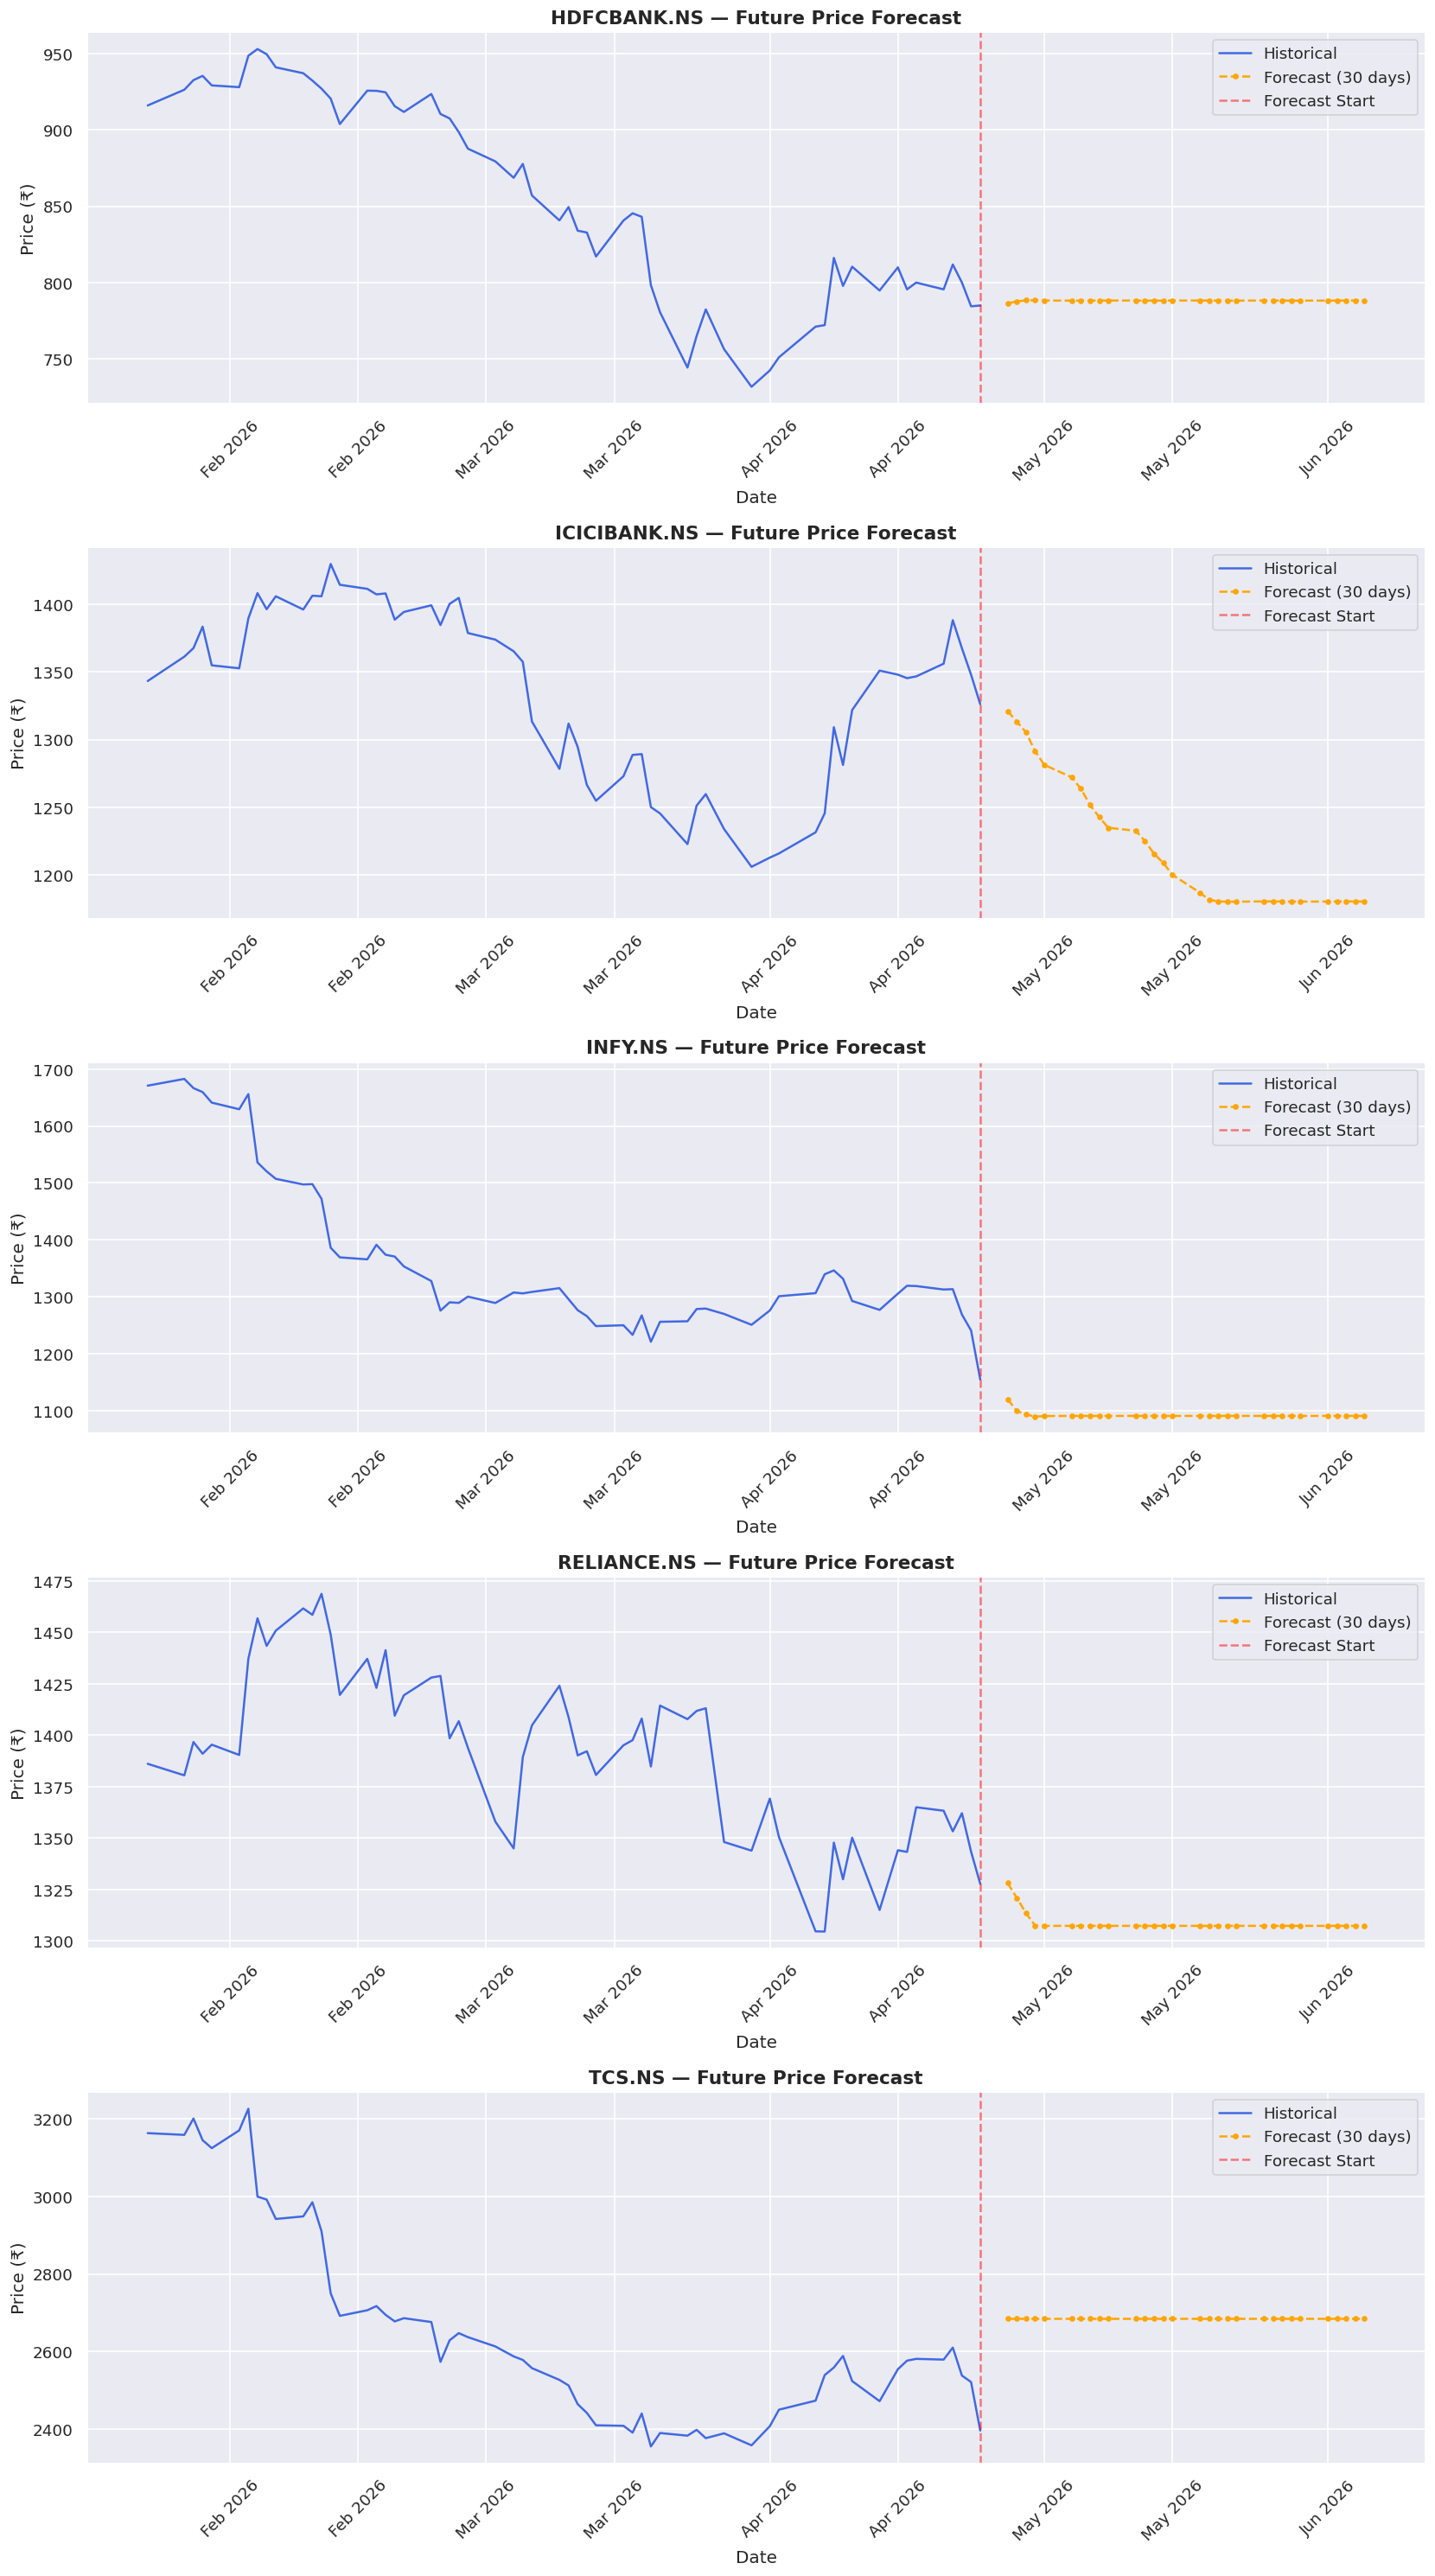

In [47]:
fig, axes = plt.subplots(len(future_results), 1, figsize=(14, 5 * len(future_results)))

if len(future_results) == 1:
    axes = [axes]

for ax, symbol in zip(axes, future_results.keys()):
    # Last 60 days of actual data for context
    actual_data = df_featured[df_featured["Symbol"] == symbol].tail(60)
    fut         = future_results[symbol]

    ax.plot(actual_data["Date"], actual_data["Close"],
            label="Historical", color="royalblue", linewidth=1.5)
    ax.plot(fut["dates"], fut["prices"],
            label=f"Forecast ({FUTURE_DAYS} days)", color="orange",
            linewidth=1.5, linestyle="--", marker="o", markersize=3)

    ax.axvline(x=actual_data["Date"].iloc[-1], color="red",
               linestyle="--", alpha=0.5, label="Forecast Start")

    ax.set_title(f"{symbol} — Future Price Forecast", fontsize=13, fontweight="bold")
    ax.set_ylabel("Price (₹)")
    ax.set_xlabel("Date")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("xgb_future_forecast.png", bbox_inches="tight")
plt.show()